#### Import libraries

In [ ]:
# Install the datasets library
!pip install datasets

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import transformers
import nltk
import spacy
import datasets
from transformers import BertTokenizer, BertModel
from datasets import load_dataset
from datasets import Dataset, DatasetDict
from sklearn.feature_extraction.text import TfidfVectorizer

#### Load dataset from HuggingFace

In [ ]:
# Load the IMDb dataset from HuggingFace
ds = load_dataset('imdb')

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [ ]:
ds['train'][0]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:
# Check the features of the training dataset
ds['train'].features

{'text': Value(dtype='string', id=None),
 'label': ClassLabel(names=['neg', 'pos'], id=None)}

In [ ]:
# Convert the training and test datasets into pandas DataFrames
ds_train = pd.DataFrame(ds['train'])
ds_test = pd.DataFrame(ds['test'])

#### Exploratory Data Analysis

In [ ]:
# Display the first few rows of the train dataset
ds_train.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [ ]:
# Get descriptive statistics of the training dataset
ds_train.describe()

,label
count,25000.00000
mean,0.50000
std,0.50001
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


In [ ]:
# Check for any missing values
ds_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


In [ ]:
# Display the first few rows of the test dataset
ds_test.head()

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0


In [ ]:
# Get descriptive statistics of the test dataset
ds_test.describe()

,label
count,25000.00000
mean,0.50000
std,0.50001
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


In [ ]:
# Check for any missing values
ds_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


In [ ]:
def length_statistics(dataset, text_col = 'text'):
    # Calculate lengths
    dataset['text_length'] = dataset[text_col].apply(lambda x: len(x.split()))

    # Statistics for text lengths
    text_length_min = dataset['text_length'].min()
    text_length_max = dataset['text_length'].max()
    text_length_mean = dataset['text_length'].mean()

    # Show results
    print(f'Text Lengths - Min: {text_length_min}, Max: {text_length_max}, Mean: {text_length_mean:.2f}')

    # Boxplot
    plt.figure(figsize = (12, 6))
    sns.boxplot(data = dataset['text_length'])
    plt.title('Boxplot of Text Length')
    plt.ylabel('Number of Words')
    plt.show()

Text Lengths - Min: 10, Max: 2470, Mean: 233.79


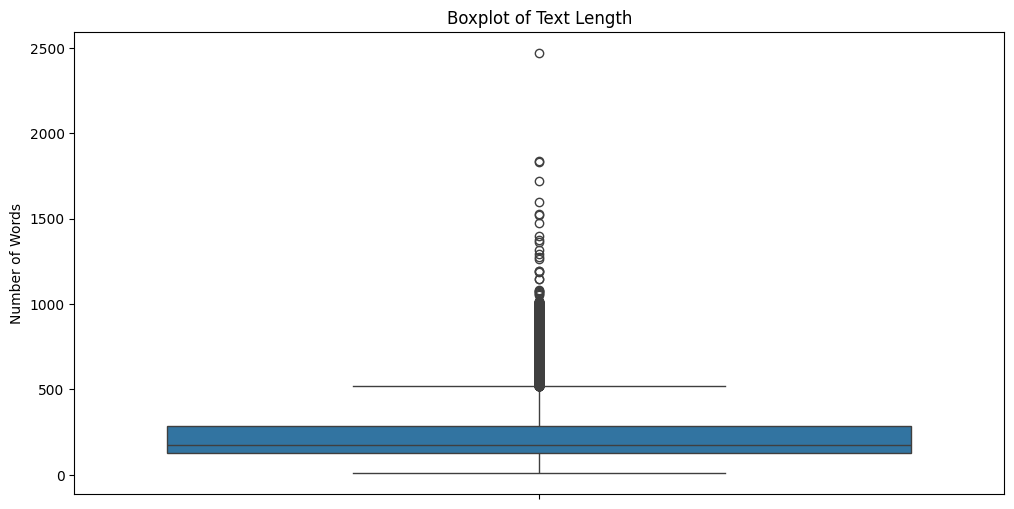

In [ ]:
# Lengths of text for train set
length_statistics(ds_train)

Text Lengths - Min: 4, Max: 2278, Mean: 228.53


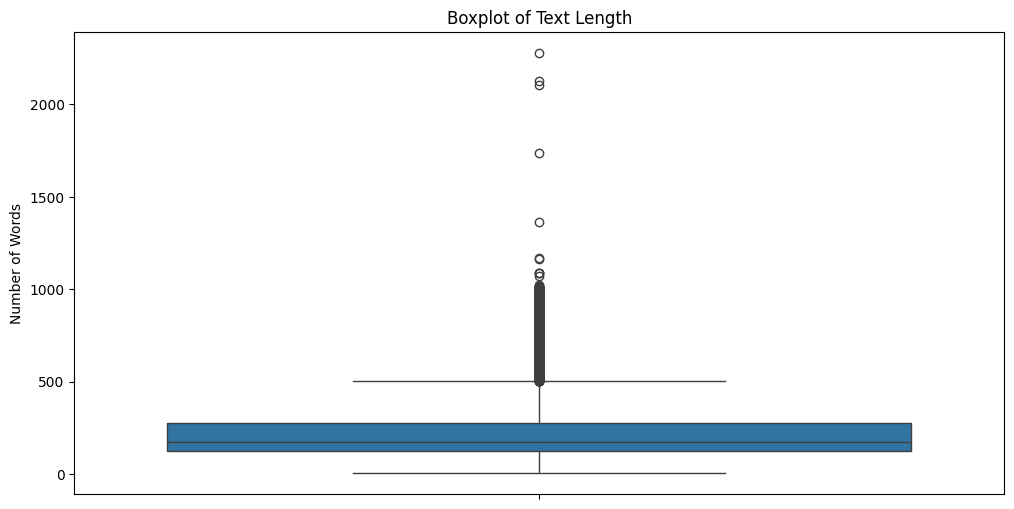

In [ ]:
# Lengths of text for test set
length_statistics(ds_test)

**Summary Analysis of the IMDB Dataset**

| Dataset       | min length   | max len      | mean len      |
| ------------- | ------------ | ------------ | ------------- |
| Train set     | 10           | 2470         | 233.79        |
| Test set      | 4            | 2278         | 228.53        |

I’ll keep all the data, as it may help analyze a wide range of opinions, which would make the model more reliable. This approach could allow the model to incorporate context from shorter reviews, provide flexibility for future analysis, and reduce the risk of missing important sentiments. Overall, the average review lengths of about 234 (training) and 229 (testing) words indicate that most reviews contain a decent amount of information.

#### Data Cleaning

##### Text Normalization

In [ ]:
# Convert to lower case, remove extra white space and special characters

import re

def text_cleaning(text):
    # lowercase
    text = text.lower()
    # remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

ds_train['text'] = ds_train['text'].apply(text_cleaning)
ds_test['text'] = ds_test['text'].apply(text_cleaning)

In [ ]:
# Remove punctuation
import string

string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
# Define the translation table to remove punctuation
no_punc = str.maketrans('', '', string.punctuation)

# Remove punctuation from 'document' column in ds_train and ds_test
ds_train['text'] = ds_train['text'].apply(lambda x: x.translate(no_punc))
ds_test['text'] = ds_test['text'].apply(lambda x: x.translate(no_punc))

In [ ]:
# Remove Stop Words
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
ds_train['text'] = ds_train['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
ds_test['text'] = ds_test['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

In [ ]:
# Display the cleaned DataFrame
print(ds_train.info())
print(ds_train.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         25000 non-null  object
 1   label        25000 non-null  int64 
 2   text_length  25000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 586.1+ KB
None
                                                text  label  text_length
0  rented curiousyellow video store controversy s...      0          288
1  curious yellow risible pretentious steaming pi...      0          214
2  avoid making type film future film interesting...      0           93
3  film probably inspired godards masculin fminin...      0          118
4  oh brotherafter hearing ridiculous film umptee...      0          311


In [ ]:
# Display an example of a cleaned text
ds_train['text'][1]

'curious yellow risible pretentious steaming pile doesnt matter ones political views film hardly taken seriously level claim frontal male nudity automatic nc isnt true ive seen rrated films male nudity granted offer fleeting views rrated films gaping vulvas flapping labia nowhere dont exist goes crappy cable shows schlongs swinging breeze clitoris sight pretentious indie movies like brown bunny treated site vincent gallos throbbing johnson trace pink visible chloe sevigny crying implying doublestandard matters nudity mentally obtuse take account one unavoidably obvious anatomical difference men women genitals display actresses appears nude cannot said man fact generally wont see female genitals american film anything short porn explicit erotica alleged doublestandard less double standard admittedly depressing ability come terms culturally insides womens bodies'

In [ ]:
# Assign the splits
train = Dataset.from_pandas(ds_train)
test = Dataset.from_pandas(ds_test)
# reconstruct both datasets into a Dataset Dict object
new_ds = DatasetDict(
    {
        'train': train,
        'test': test
    },
)
# View the resulting dataset dict object
new_ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 25000
    })
})

In [ ]:
# Convert Dataset Dict to pd dfs

train_df = pd.DataFrame(new_ds['train'])
test_df = pd.DataFrame(new_ds['test'])

In [ ]:
# Save the cleaned DataFrames to CSV files
train_df.to_csv('train_df.csv', index = False)
test_df.to_csv('test_df.csv', index = False)


In [ ]:
# Download the cleaned training DataFrame CSV file
from google.colab import files
files.download('train_df.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Download the cleaned test DataFrame CSV file
files.download('test_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>